In [22]:
import h5py
import numpy as np
import faiss
import pandas as pd

import seaborn
import os
import matplotlib.pyplot as plt

In [2]:
def embedding_setup(path):
    ids = []
    embeddings = []

    with h5py.File(path, "r") as hf:
        for sequenceID in hf.keys():
            dataset = hf[sequenceID]
            # 1. On crée un array vide de la bonne taille en Float32
            # dataset.shape te donne la dimension du vecteur (ex: 1024)
            vec = np.empty(dataset.shape, dtype='float32')
            
            # 2. On force la lecture directe dedans
            dataset.read_direct(vec)
            
            ids.append(sequenceID)
            embeddings.append(vec)
            
    # On empile tout à la fin
    embed_array = np.array(embeddings).astype('float32')
    
    return ids, embed_array
# have to use this function twice : once on query once on reference

In [3]:
def index_search_distances(emb_query,emb_ref):
  
    
    faiss.normalize_L2(emb_query)
    faiss.normalize_L2(emb_ref) #need to normalize to do the Inner product (dot product for cosine similarity)

    d = 1024  #tell faiss how many dimension we're working with
    index = faiss.IndexFlatIP(d) #indexflat = no compression (avoid info loss)  / IP = inner or dot product = the cosine similarity
    index.add(emb_ref) #store the information of organism2 to search through

    distances, indices = index.search(emb_query, k=1)#look through organism2 to compare with organism1 prot and look for the closest neighbor only
#distances store the distances, indices = the row number that match the indice of the list of ids !! genius congrats me :)

    return distances,indices

In [4]:
def extractname_frompath(organismpath) :
    filename = os.path.basename(organismpath)
    nomseul = os.path.splitext(filename)[0]
    label= nomseul.split('_')[0]

    return label

In [7]:
path_Org1 = "/home/cassandre/stage/Cassandre/Embeddings/PROTT5_AVERAGEPOOLING/chimp_embedding_protT5_uniprot_proteinembeddings.h5"
path_Org2 = "/home/cassandre/stage/Cassandre/Embeddings/PROTT5_AVERAGEPOOLING/homosapiens_embedding_protT5_uniprot_proteinembeddings.h5"

In [30]:
        
id1,emb1 = embedding_setup(path_Org1)
id2,emb2 = embedding_setup(path_Org2)
    
label1 = extractname_frompath(path_Org1)
label2 = extractname_frompath(path_Org2)

distances1_2, indices1_2= index_search_distances(emb1,emb2)
distances2_1, indices2_1= index_search_distances(emb2, emb1)
    # run the function twice to get all the closest neighbor

all_closest_neighbors = np.concatenate([distances1_2.flatten(),distances2_1.flatten()])


neighbor_names_2_1 = [id1[idx[0]] for idx in indices2_1]
neighbor_names_1_2 = [id2[idx[0]] for idx in indices1_2]


df1 = pd.DataFrame({'proteinID' : id1, 'closest_Neighbor' : neighbor_names_1_2, 'similarité' : distances1_2.flatten(), 'species' : label1  })
df2 = pd.DataFrame({'proteinID' : id2, 'closest_Neighbor' : neighbor_names_2_1, 'similarité' : distances2_1.flatten(), 'species' : label2  })

df_allorganism = pd.concat([df1,df2],ignore_index=True)
df_allorganism = df_allorganism.sort_values(by=["similarité"])

print(df_allorganism.head(500).to_string())


                            proteinID                closest_Neighbor  similarité      species
3065   tr|A0A2I3S1V5|A0A2I3S1V5_PANTR           sp|Q4W4Y0|DRIP1_HUMAN    0.392538        chimp
43352  tr|A0A075B6W9|A0A075B6W9_HUMAN  tr|A0A2I3TSQ9|A0A2I3TSQ9_PANTR    0.446657  homosapiens
2743   tr|A0A2I3RY06|A0A2I3RY06_PANTR           sp|Q96LB4|VATG3_HUMAN    0.458237        chimp
29904           sp|P63121|VP113_HUMAN          tr|K7DAA7|K7DAA7_PANTR    0.464701  homosapiens
29905           sp|P63124|VPK04_HUMAN          tr|H2Q8K5|H2Q8K5_PANTR    0.486187  homosapiens
43381  tr|A0A075B714|A0A075B714_HUMAN  tr|A0A2I3S0Z7|A0A2I3S0Z7_PANTR    0.494641  homosapiens
43379  tr|A0A075B712|A0A075B712_HUMAN  tr|A0A2I3S0Z7|A0A2I3S0Z7_PANTR    0.499738  homosapiens
3577   tr|A0A2I3S7U6|A0A2I3S7U6_PANTR  tr|A0A1W2PRE2|A0A1W2PRE2_HUMAN    0.500129        chimp
5405   tr|A0A2I3STH8|A0A2I3STH8_PANTR           sp|Q96M78|FEAS2_HUMAN    0.502565        chimp
6276   tr|A0A2I3T3B7|A0A2I3T3B7_PANTR  tr|A0A1W2PR

In [42]:
Q1 = df_allorganism['similarité'].quantile(0.25)
Q3 = df_allorganism['similarité'].quantile(0.75)

IQR = Q3 - Q1

cutoff_iqr = Q1 - 1.5 * IQR

deviationstd_similarity = df_allorganism['similarité'].std()

outliers_cutoff= mean_similarity-(3*deviationstd_similarity)

print(f"Seuil IQR : {cutoff_iqr:.4f}")
print(f"Nombre d'outliers avec IQR : {len(df_allorganism[df_allorganism['similarité'] < cutoff_iqr])}")

print(deviationstd_similarity)
print(outliers_cutoff)
print(f"Nombre d'outliers avec IQR : {len(df_allorganism[df_allorganism['similarité'] < outliers_cutoff])}")



Seuil IQR : 0.9652
Nombre d'outliers avec IQR : 8190
0.06236809
0.785849642008543
Nombre d'outliers avec IQR : 1343


Text(0, 0.5, 'Densité')

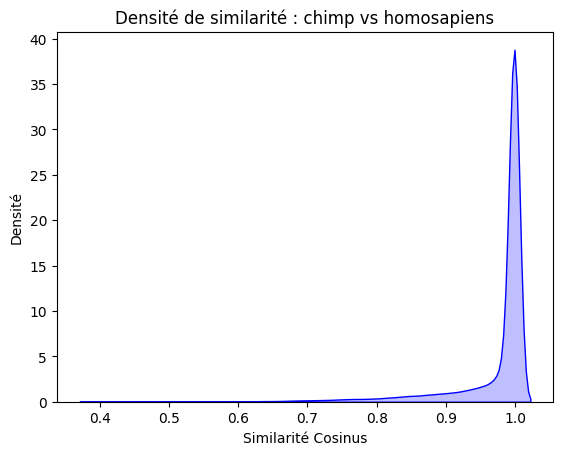

In [ ]:
seaborn.kdeplot(data = df_allorganism,x="similarité",fill=True, color="blue")
plt.title(f"Densité de similarité : {label1} vs {label2}")
plt.xlabel("Similarité Cosinus") #1 = identité, 0 = très très différent
plt.ylabel("Densité")

In [39]:
#code to add protein under the cutoff distance to a list 
# can then be used in the other umap print script so i can change the color of the outliers


is_outlier = df_allorganism['similarité'] < cutoff_iqr

outlier_list = df_allorganism.loc[is_outlier, 'proteinID'].tolist()

print(f"Nombre d'IDs dans la liste : {len(outlier_list)}")

outlier_list

Nombre d'IDs dans la liste : 8190


['tr|A0A2I3S1V5|A0A2I3S1V5_PANTR',
 'tr|A0A075B6W9|A0A075B6W9_HUMAN',
 'tr|A0A2I3RY06|A0A2I3RY06_PANTR',
 'sp|P63121|VP113_HUMAN',
 'sp|P63124|VPK04_HUMAN',
 'tr|A0A075B714|A0A075B714_HUMAN',
 'tr|A0A075B712|A0A075B712_HUMAN',
 'tr|A0A2I3S7U6|A0A2I3S7U6_PANTR',
 'tr|A0A2I3STH8|A0A2I3STH8_PANTR',
 'tr|A0A2I3T3B7|A0A2I3T3B7_PANTR',
 'tr|A0A2I3RC02|A0A2I3RC02_PANTR',
 'tr|A0A2I3TFY6|A0A2I3TFY6_PANTR',
 'tr|A0A075B6Z8|A0A075B6Z8_HUMAN',
 'sp|Q6ZRU5|YQ032_HUMAN',
 'tr|A0A2I3TM26|A0A2I3TM26_PANTR',
 'tr|A0A2I3RF79|A0A2I3RF79_PANTR',
 'tr|A0A2I3RGA1|A0A2I3RGA1_PANTR',
 'tr|A0A2I3TB88|A0A2I3TB88_PANTR',
 'tr|A0A2I3T272|A0A2I3T272_PANTR',
 'tr|A0A2I3RXB3|A0A2I3RXB3_PANTR',
 'tr|A0A2I3SQP7|A0A2I3SQP7_PANTR',
 'tr|A0A2I3SLB7|A0A2I3SLB7_PANTR',
 'tr|H2RF37|H2RF37_PANTR',
 'tr|A0A2I3S606|A0A2I3S606_PANTR',
 'tr|A0A2I3SGZ4|A0A2I3SGZ4_PANTR',
 'tr|A0A2I3TN86|A0A2I3TN86_PANTR',
 'tr|A0A075B711|A0A075B711_HUMAN',
 'sp|Q99622|C10_HUMAN',
 'tr|H2R5R3|H2R5R3_PANTR',
 'tr|A0A2I3RX62|A0A2I3RX62_PANTR',
 'tr

In [46]:
output_folder = "/home/cassandre/stage/Cassandre/panthr_text/"


outlier_org1 = [p for p in outlier_list if p in id1]
outlier_org2 = [p for p in outlier_list if p in id2]

def clean_uniprot(id_list):
    return [p.split('|')[1] if '|' in p else p for p in id_list]

# Nettoyage listes
id1_clean = clean_uniprot(id1)
id2_clean = clean_uniprot(id2)
outliers_org1_clean = clean_uniprot(outlier_org1)
outliers_org2_clean = clean_uniprot(outlier_org2)


with open(output_folder + "background_" + label1 + ".txt", "w") as f:
    f.write("\n".join(id1_clean))

with open(output_folder + "outliers_" + label1 + ".txt", "w") as f:
    f.write("\n".join(outliers_org1_clean))


with open(output_folder + "background_" + label2 + ".txt", "w") as f:
    f.write("\n".join(id2_clean))


with open(output_folder + "outliers_" + label2 + ".txt", "w") as f:
    f.write("\n".join(outliers_org2_clean))


